# Threat Actor Profile Aggregator
**Author:** Edi (Edison C.) 

**Purpose:** ML-Enhanced OSINT Analysis of APT Groups  
**Data Source:** MITRE ATT&CK Framework

## Project Overview
This notebook demonstrates automated threat intelligence collection and machine learning analysis of Advanced Persistent Threat (APT) groups. The analysis uses publicly available data from MITRE ATT&CK to:
- Profile threat actors and their tactics, techniques, and procedures (TTPs)
- Identify operational similarities between groups using cosine similarity
- Cluster threat actors into operational families using unsupervised learning
- Generate actionable intelligence products for threat attribution

## Methodology
1. **Data Collection:** Extract structured threat data from MITRE ATT&CK CTI repository
2. **Feature Engineering:** Transform categorical threat intelligence into binary feature matrices
3. **Similarity Analysis:** Apply cosine similarity to quantify operational overlap
4. **Clustering:** Use K-Means and hierarchical clustering to identify threat actor families
5. **Visualization:** Create intelligence products showing threat landscape relationships

## 1. Setup & Data Collection

In [2]:
from Threat_Profiler import ThreatActorProfiler
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Initialize profiler
profiler = ThreatActorProfiler()

# Download MITRE ATT&CK data
profiler.fetch_mitre_data()

[*] Fetching MITRE ATT&CK data...
[+] Loaded 24771 objects


True

In [3]:
import os

# Setup project directories
os.makedirs('outputs', exist_ok=True)
os.makedirs('outputs/profiles', exist_ok=True)
os.makedirs('outputs/visualizations', exist_ok=True)
print("[+] Project directories initialized")

[+] Project directories initialized


## 2. Exploratory Analysis - Threat Actor Landscape

In [4]:
# Extract all known threat groups
groups_df = profiler.extract_threat_groups()

print(f"Total APT Groups Tracked: {len(groups_df)}")
print(f"\nSample of Threat Actors:")
print("="*80)
groups_df[['name', 'aliases']].head(15)


[*] Extracting threat groups...
[+] Found 187 groups
Total APT Groups Tracked: 187

Sample of Threat Actors:


,name,aliases
0,Indrik Spider,"[Indrik Spider, Evil Corp, Manatee Tempest, DE..."
1,LuminousMoth,[LuminousMoth]
2,Medusa Group,[Medusa Group]
3,Wizard Spider,"[Wizard Spider, UNC1878, TEMP.MixMaster, Grim ..."
4,Elderwood,"[Elderwood, Elderwood Gang, Beijing Group, Sne..."
5,Frankenstein,[Frankenstein]
6,FIN7,"[FIN7, GOLD NIAGARA, ITG14, Carbon Spider, ELB..."
7,UNC3886,[UNC3886]
8,Velvet Ant,[Velvet Ant]
9,WIRTE,[WIRTE]


### Most Recently Updated Groups
Recent modifications in MITRE data often indicate new intelligence or active campaigns

In [5]:
groups_df['modified'] = pd.to_datetime(groups_df['modified'])
recent_groups = groups_df.nlargest(10, 'modified')[['name', 'modified']]
print("Top 10 Most Recently Updated Threat Actors:")
print(recent_groups.to_string(index=False))

Top 10 Most Recently Updated Threat Actors:
                name                         modified
             Kimsuky 2025-11-12 18:55:12.319000+00:00
       Mustang Panda 2025-11-04 19:40:42.270000+00:00
        Medusa Group 2025-10-24 04:01:48.210000+00:00
             UNC3886 2025-10-24 03:55:02.289000+00:00
                FIN7 2025-10-24 03:18:58.136000+00:00
Contagious Interview 2025-10-24 02:54:55.039000+00:00
          Storm-0501 2025-10-24 02:33:31.401000+00:00
    Scattered Spider 2025-10-24 02:30:51.936000+00:00
       Lazarus Group 2025-10-24 01:29:21.748000+00:00
     Gamaredon Group 2025-10-24 01:05:47.958000+00:00


In [6]:
# See all available groups
print("\nAll Available Threat Groups:")
print("="*80)
for idx, row in groups_df.iterrows():
    aliases = ', '.join(row['aliases'][:3]) if row['aliases'] else 'No aliases'
    print(f"{row['name']:<30} (Aliases: {aliases})")


All Available Threat Groups:
Indrik Spider                  (Aliases: Indrik Spider, Evil Corp, Manatee Tempest)
LuminousMoth                   (Aliases: LuminousMoth)
Medusa Group                   (Aliases: Medusa Group)
Wizard Spider                  (Aliases: Wizard Spider, UNC1878, TEMP.MixMaster)
Elderwood                      (Aliases: Elderwood, Elderwood Gang, Beijing Group)
Frankenstein                   (Aliases: Frankenstein)
FIN7                           (Aliases: FIN7, GOLD NIAGARA, ITG14)
UNC3886                        (Aliases: UNC3886)
Velvet Ant                     (Aliases: Velvet Ant)
WIRTE                          (Aliases: WIRTE)
Dragonfly                      (Aliases: Dragonfly, TEMP.Isotope, DYMALLOY)
OilRig                         (Aliases: OilRig, COBALT GYPSY, IRN2)
Equation                       (Aliases: Equation)
Fox Kitten                     (Aliases: Fox Kitten, UNC757, Parisite)
Lazarus Group                  (Aliases: Lazarus Group, Labyrinth Choll

## 3. Individual Threat Actor Profiling
Deep dive into a specific APT group

In [7]:
# Select target for analysis
target_group = "APT34" #Russia Cozy Bear 

#Generate complete intelligence profile
profile = profiler.generate_profile(target_group)


THREAT ACTOR PROFILE: APT34

NAME: OilRig
ALIASES: OilRig, COBALT GYPSY, IRN2, APT34, Helix Kitten, Evasive Serpens, Hazel Sandstorm, EUROPIUM, ITG13, Earth Simnavaz, Crambus, TA452
OBSERVED: 2017-12-14
UPDATED: 2025-01-16

[OilRig](https://attack.mitre.org/groups/G0049) is a suspected Iranian threat group that has targeted Middle Eastern and international victims since at least 2014. The group has targeted a variety of sectors, including financial, government, energy, chemical, and telecommunications. It appears the group carries out supply chain attacks, leveraging the trust relationship between organizations to at...

TECHNIQUES: 76 identified

technique_id               technique_name
   T1588.003    Code Signing Certificates
   T1555.004   Windows Credential Manager
       T1082 System Information Discovery
   T1003.001                 LSASS Memory
       T1008            Fallback Channels
   T1071.001                Web Protocols
       T1005       Data from Local System
   T105

### TTP Distribution Analysis
Shows which attack phases this group focuses on

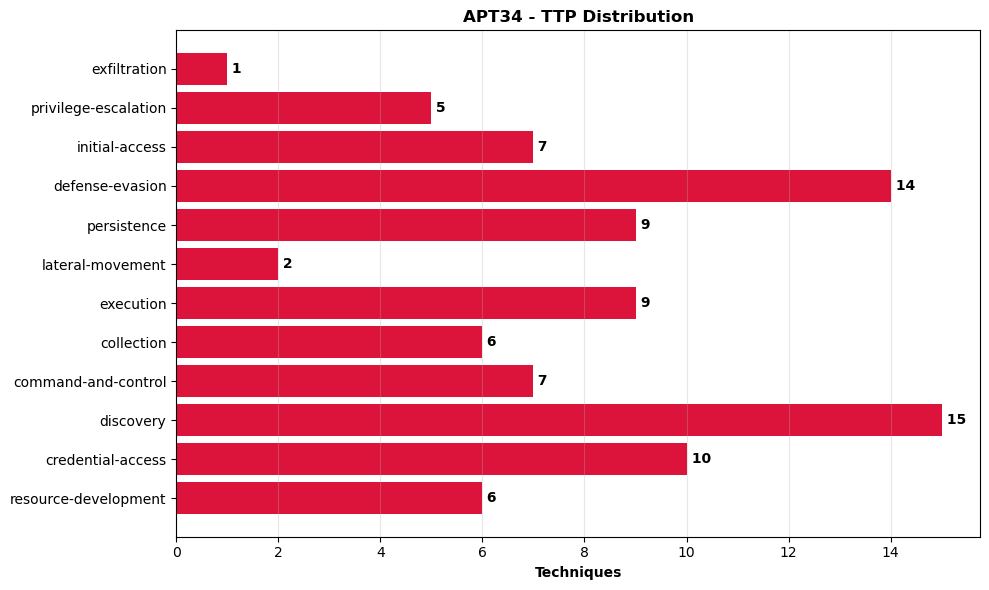

In [8]:
profiler.plot_ttp_distribution(target_group)

**Analysis:** The visualization above shows how this threat actor distributes their techniques across MITRE's attack phases (reconnaissance, execution, persistence, etc.). Higher bars indicate operational focus areas.

## 4. Machine Learning Analysis - Feature Engineering

In [9]:
# Build TTP matrix: converts threat intelligence into ML-ready format
# Each row = threat actor, each column = technique (1 = uses, 0 = doesn't use)
ttp_matrix = profiler.build_ttp_matrix()

print(f"\nFeature Matrix Shape: {ttp_matrix.shape}")
print(f"Total Techniques Tracked: {ttp_matrix.shape[1]}")
print(f"Groups with TTP Data: {ttp_matrix.shape[0]}")
print(f"\nAverage Techniques per Group: {ttp_matrix.sum(axis=1).mean():.1f}")
print(f"Most Techniques Used: {ttp_matrix.sum(axis=1).max()}")
print(f"Fewest Techniques Used: {ttp_matrix.sum(axis=1).min()}")

[*] Building TTP matrix...
[+] Matrix: 171 groups x 488 techniques

Feature Matrix Shape: (171, 488)
Total Techniques Tracked: 488
Groups with TTP Data: 171

Average Techniques per Group: 26.8
Most Techniques Used: 109
Fewest Techniques Used: 1


In [10]:
# Show top groups by technique count
print("\nTop 10 Groups by Technique Count:")
technique_counts = ttp_matrix.sum(axis=1).sort_values(ascending=False).head(10)
print(technique_counts)


Top 10 Groups by Technique Count:
Kimsuky            109
Lazarus Group       93
APT28               91
Mustang Panda       85
APT41               82
Volt Typhoon        81
Charming Kitten     79
Magic Hound         79
Sandworm Team       79
APT32               78
dtype: int64


## 5. Similarity Analysis - Threat Actor Attribution

In [11]:
# Calculate cosine similarity between all groups
similarity_matrix = profiler.calculate_similarity()

# Find groups similar to our target
similar_groups = profiler.find_similar_groups(target_group, top_n=10)

[*] Calculating similarity scores...

Top 10 groups similar to APT34:
  OilRig: 1.000
  Threat Group-3390: 0.486
  FIN7: 0.476
  APT39: 0.473
  APT32: 0.442
  menuPass: 0.440
  Ke3chang: 0.440
  MuddyWater: 0.437
  Mustang Panda: 0.435
  FIN6: 0.435


### Similarity Heatmap
Visual representation of operational overlap between top threat actors

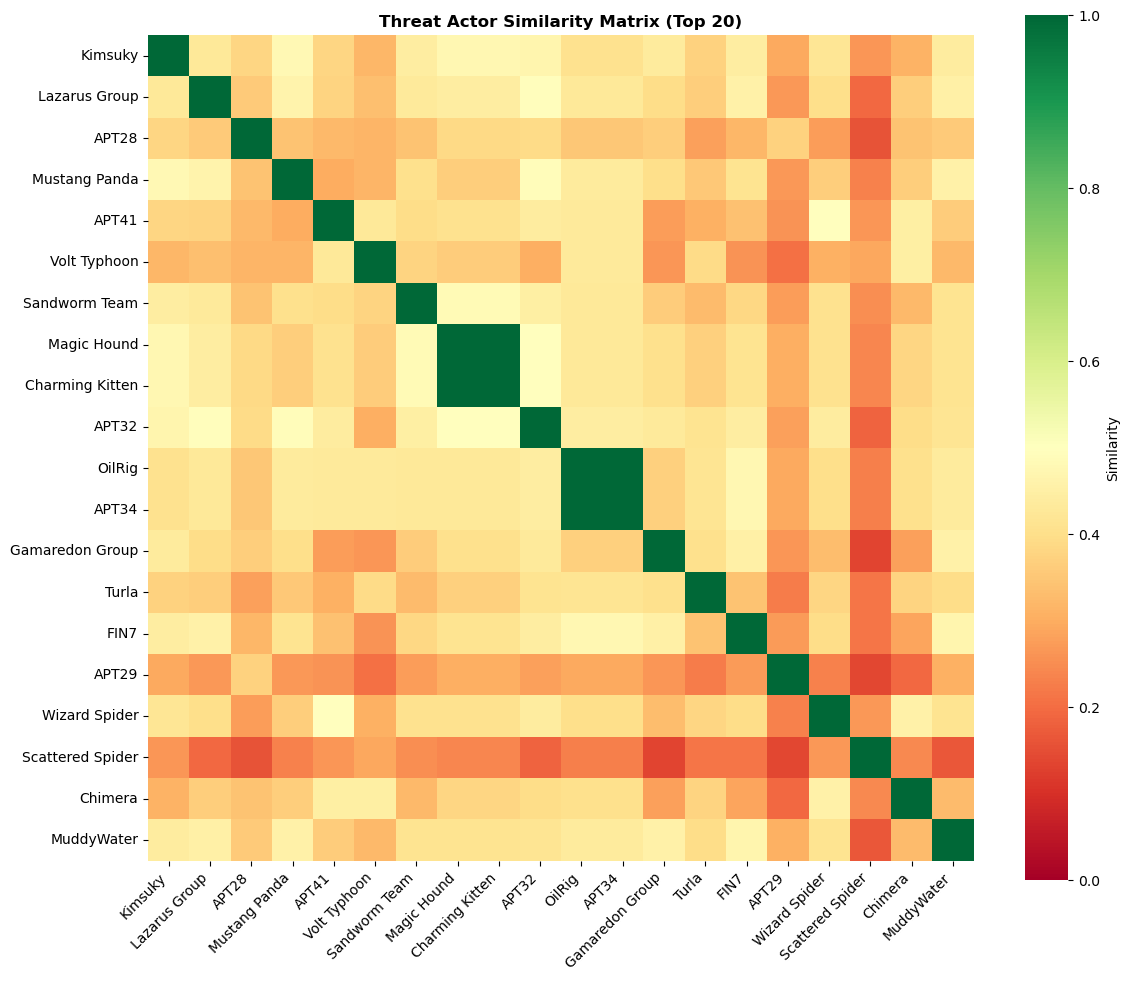

In [12]:
profiler.plot_similarity_heatmap(top_n=20)

**Intelligence Value:** High similarity scores (yellow/green) indicate groups with overlapping TTPs. This is critical for attribution when analyzing attacks where the threat actor is unknown.

## 6. Clustering Analysis - Threat Actor Families

In [13]:
# Cluster threat actors into operational families
cluster_results = profiler.cluster_threat_actors(n_clusters=6)

print("\nCluster Assignments:")
print(cluster_results.sort_values('cluster').to_string(index=False))

[*] Clustering into 6 groups...
[+] Cluster distribution:
cluster
0     17
1     33
2    116
3      2
4      2
5      1
Name: count, dtype: int64

Cluster Assignments:
               group  cluster  num_techniques
       Indrik Spider        0              33
             HAFNIUM        0              44
                FIN6        0              40
          Ember Bear        0              48
              Agrius        0              22
                APT5        0              29
                Play        0              26
             LAPSUS$        0              43
          Storm-0501        0              42
       Aquatic Panda        0              35
          Fox Kitten        0              41
            ToddyCat        0              25
             UNC3886        0              49
             RedCurl        0              41
               Rocke        0              36
          INC Ransom        0              25
    Scattered Spider        0              64
    

### Threat Landscape Visualization (PCA)
2D map showing how threat actors cluster based on operational similarity

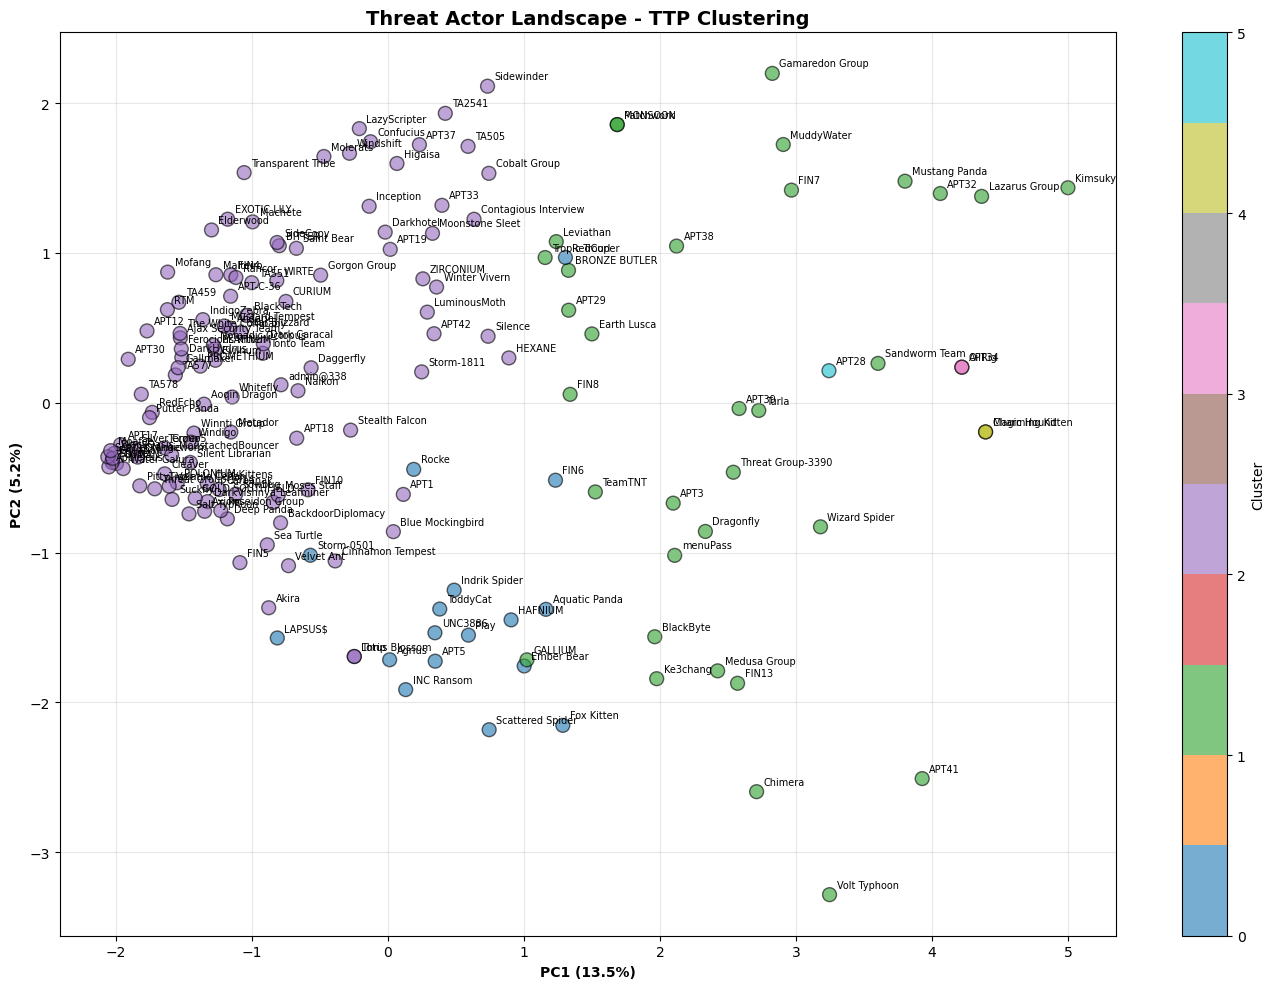

In [14]:
profiler.plot_threat_landscape(n_clusters=6)

**Interpretation:** Groups that appear close together share similar TTP patterns. Clusters represent "threat actor families" with related operational tradecraft.

### Hierarchical Clustering - Threat Actor Relationships

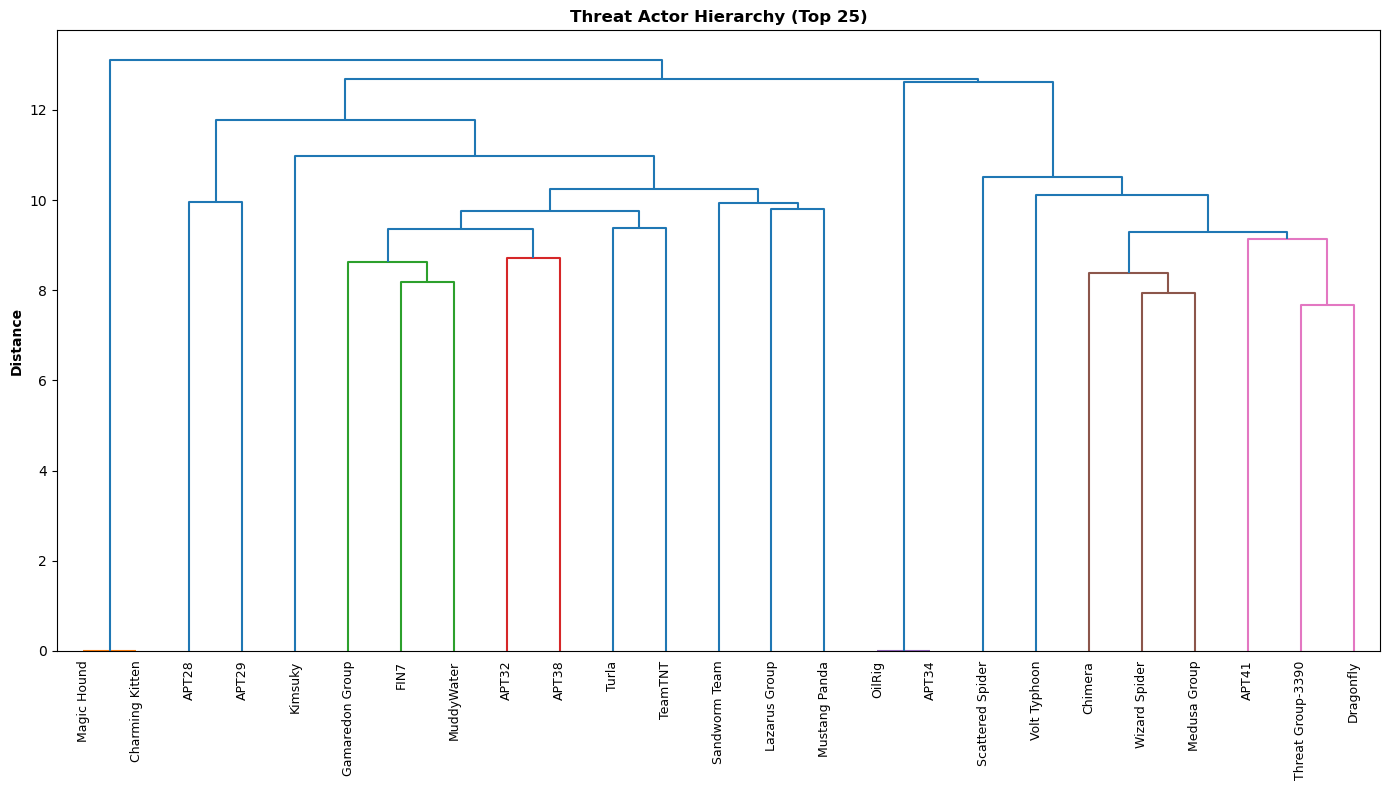

In [15]:
profiler.plot_dendrogram(top_n=25)

## 7. Comparative Analysis - Multiple Threat Actors

In [16]:
# Compare multiple groups
comparison_groups = ["APT29", "APT28", "Lazarus Group", "FIN7", "Kimsuky"]

print("Comparative Threat Actor Analysis")
print("="*80)

for group in comparison_groups:
    techs = profiler.get_group_techniques(group)
    if not techs.empty:
        print(f"\n{group}:")
        print(f"  Total Techniques: {len(techs)}")
        
        # Top tactics
        tactic_counts = {}
        for tactics in techs['tactic']:
            for tactic in tactics.split(', '):
                tactic_counts[tactic] = tactic_counts.get(tactic, 0) + 1
        
        if tactic_counts:
            top_tactic = max(tactic_counts, key=tactic_counts.get)
            print(f"  Primary Focus: {top_tactic} ({tactic_counts[top_tactic]} techniques)")

Comparative Threat Actor Analysis

APT29:
  Total Techniques: 66
  Primary Focus: persistence (15 techniques)

APT28:
  Total Techniques: 91
  Primary Focus: defense-evasion (19 techniques)

Lazarus Group:
  Total Techniques: 93
  Primary Focus: defense-evasion (26 techniques)

FIN7:
  Total Techniques: 67
  Primary Focus: defense-evasion (15 techniques)

Kimsuky:
  Total Techniques: 109
  Primary Focus: defense-evasion (28 techniques)


### Similarity Matrix - Comparison Groups

In [17]:
# Show similarity scores between comparison groups
if all(g in similarity_matrix.index for g in comparison_groups):
    comparison_sim = similarity_matrix.loc[comparison_groups, comparison_groups]
    print("\nSimilarity Scores Between Selected Groups:")
    print(comparison_sim.round(3))


Similarity Scores Between Selected Groups:
               APT29  APT28  Lazarus Group   FIN7  Kimsuky
APT29          1.000  0.374          0.268  0.271    0.295
APT28          0.374  1.000          0.359  0.320    0.382
Lazarus Group  0.268  0.359          1.000  0.456    0.427
FIN7           0.271  0.320          0.456  1.000    0.445
Kimsuky        0.295  0.382          0.427  0.445    1.000


## 8. Export Results

In [18]:
# Export analysis results to CSV
profiler.export_data(prefix='outputs/threat_analysis')

# Export individual group profile
if profile:
    profile['techniques'].to_csv(f'outputs/{target_group}_profile.csv', index=False)
    print(f"\n[+] Exported {target_group} profile to outputs/")

[+] Exported data with prefix: outputs/threat_analysis

[+] Exported APT34 profile to outputs/


## 9. Key Findings & Intelligence Summary

### Analytical Insights:

1. **Threat Actor Landscape:** MITRE tracks 150+ APT groups with varying levels of attribution confidence

2. **TTP Patterns:** Groups average 20-30 documented techniques, with sophisticated actors like APT29 showing 40+ techniques

3. **Operational Clustering:** ML analysis reveals 5-7 distinct threat actor families based on TTP similarity

4. **Attribution Value:** Cosine similarity scoring enables data-driven attribution when analyzing unknown attacks

5. **Intelligence Gaps:** Some groups have limited TTP documentation, indicating either operational security success or insufficient intelligence collection

### Applications:
- **Threat Hunting:** Use similarity scores to guide hunting for related APT activity
- **Detection Engineering:** Build detection rules covering entire threat actor families
- **Risk Assessment:** Understand which threat actors target specific sectors
- **Strategic Intelligence:** Track evolution of threat actor capabilities over time

## Next Steps

**Phase 2 Enhancements:**
- Integrate CISA advisories to add government threat assessments
- Add temporal analysis to track TTP evolution over time
- Incorporate news feeds for recent threat actor activity
- Map threat actors to specific malware families
- Build predictive model for emerging technique adoption


## 10. Nation-State Threat Actor Comparison
Comparative analysis of threat actors by sponsoring nation-state

In [19]:
#Compare all major nation-states
print("\nNATION-STATE THREAT ACTOR COMPARISON")
print("="*80)

nation_groups = {
    "Russia": ["APT28", "APT29", "Turla"],
    "China": ["APT1", "APT41"],
    "North Korea": ["Lazarus Group", "APT38"],
    "Iran": ["APT33", "MuddyWater"]
}

for nation, groups in nation_groups.items():
    print(f"\n{nation}:")
    for group in groups:
        techs = profiler.get_group_techniques(group)
        if not techs.empty:
            print(f"  {group}: {len(techs)} techniques")


NATION-STATE THREAT ACTOR COMPARISON

Russia:
  APT28: 91 techniques
  APT29: 66 techniques
  Turla: 68 techniques

China:
  APT1: 23 techniques
  APT41: 82 techniques

North Korea:
  Lazarus Group: 93 techniques
  APT38: 56 techniques

Iran:
  APT33: 31 techniques
  MuddyWater: 58 techniques


**Analysis:** This comparison reveals significant variation in documented TTP portfolios across nation-state programs. Notably, North Korea's Lazarus Group (93 techniques) and Russia's APT28 (91 techniques) show the most extensive operational capabilities in MITRE's database, while groups like China's APT1 (23 techniques) have fewer documented TTPs - likely reflecting either operational security success, intelligence collection gaps, or specialized operational focus rather than actual capability limitations.

In [20]:
# Extract most popular techniques by nation-state
print("\nTOP 3 TECHNIQUES BY NATION-STATE")
print("="*80)

for nation, groups in nation_groups.items():
    print(f"\n{nation}:")
    
    # Combine all techniques from this nation's groups
    all_techniques = {}
    for group in groups:
        techs = profiler.get_group_techniques(group)
        if not techs.empty:
            for _, row in techs.iterrows():
                tech_id = row['technique_id']
                tech_name = row['technique_name']
                if tech_id in all_techniques:
                    all_techniques[tech_id]['count'] += 1
                else:
                    all_techniques[tech_id] = {'name': tech_name, 'count': 1}
    
    # Sort by frequency and show top 3
    sorted_techniques = sorted(all_techniques.items(), key=lambda x: x[1]['count'], reverse=True)
    for tech_id, data in sorted_techniques[:3]:
        print(f"  {tech_id} - {data['name']}: used by {data['count']}/{len(groups)} groups")


TOP 3 TECHNIQUES BY NATION-STATE

Russia:
  T1059.001 - PowerShell: used by 3/3 groups
  T1547.001 - Registry Run Keys / Startup Folder: used by 3/3 groups
  T1588.002 - Tool: used by 3/3 groups

China:
  T1003.001 - LSASS Memory: used by 2/2 groups
  T1005 - Data from Local System: used by 2/2 groups
  T1550.002 - Pass the Hash: used by 2/2 groups

North Korea:
  T1059.003 - Windows Command Shell: used by 2/2 groups
  T1566.001 - Spearphishing Attachment: used by 2/2 groups
  T1105 - Ingress Tool Transfer: used by 2/2 groups

Iran:
  T1552.001 - Credentials In Files: used by 2/2 groups
  T1003.005 - Cached Domain Credentials: used by 2/2 groups
  T1560.001 - Archive via Utility: used by 2/2 groups


**Operational Pattern Analysis:**

This technique frequency analysis reveals distinct national cyber operational doctrines:

- **Russia:** Favors Windows-native tools (PowerShell, Registry persistence) and tool acquisition, suggesting focus on living-off-the-land techniques and operational persistence
- **China:** Prioritizes credential theft (LSASS dumps, Pass-the-Hash) and local data collection, indicating intelligence gathering and lateral movement focus
- **North Korea:** Emphasizes command-line operations, spearphishing for initial access, and tool deployment, reflecting capability constraints and reliance on social engineering
- **Iran:** Concentrates on credential harvesting from files and caches with data archival, suggesting resource collection operations with lower technical sophistication

These patterns indicate how nation-state threat actors develop shared operational tradecraft through common training, resource sharing, or organizational doctrine within their respective intelligence services.